# ⚔️ Lab 3: The Showdown — K-Means vs DBSCAN

Two clustering algorithms enter. Same data. Different philosophies:

- 🔵 **K-Means:** *"Tell me how many groups (K), and I'll draw round territories around centroids."*
- 🟢 **DBSCAN:** *"I don't need K. Crowded regions are clusters — whatever their shape. Lonely points are NOISE."*

This is a short lab — mostly **running cells and watching plots**. Your job is to observe who wins each round and understand WHY. 🥊

*(No dataset needed — we generate the data ourselves!)*

In [1]:
!pip install numpy matplotlib scikit-learn

### 🛠️ Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_blobs, make_moons

def plot_duel(X, km_labels, db_labels, title):
    """Plot K-Means vs DBSCAN results side by side. DBSCAN noise points are shown as gray X marks."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].scatter(X[:, 0], X[:, 1], c=km_labels, cmap='tab10', alpha=0.7)
    axes[0].set_title('🔵 K-Means')

    noise = db_labels == -1
    axes[1].scatter(X[~noise, 0], X[~noise, 1], c=db_labels[~noise], cmap='tab10', alpha=0.7)
    axes[1].scatter(X[noise, 0], X[noise, 1], c='gray', marker='x', s=60, label='Noise 🗑️')
    axes[1].set_title('🟢 DBSCAN')
    if noise.any():
        axes[1].legend()

    plt.suptitle(title, fontsize=14)
    plt.show()

print("⚔️ Arena ready!")

⚔️ Arena ready!


### 🥊 Round 1: Nice Round Blobs — K-Means' Home Turf

First, fair conditions: three clean, round groups. Exactly what K-Means assumes the world looks like.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128465 (\N{WASTEBASKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


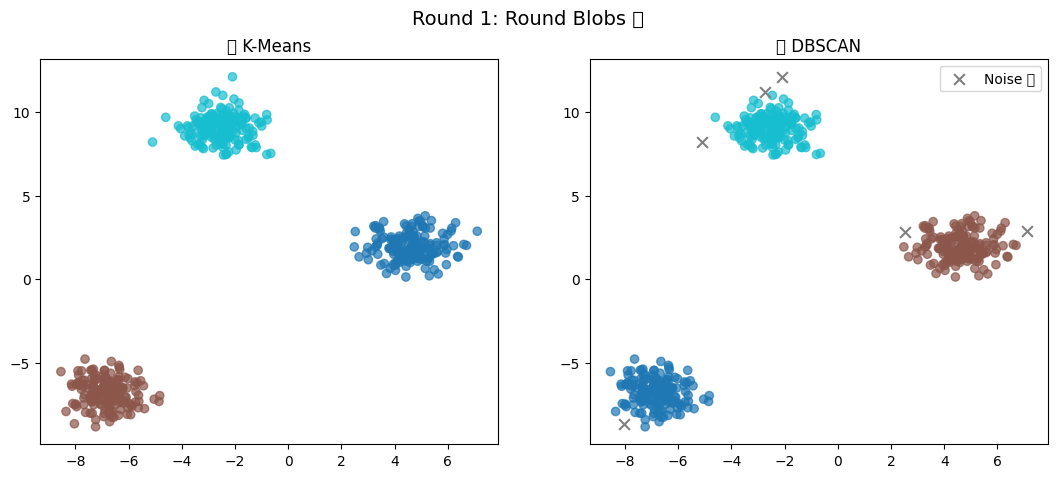

In [3]:
X_blobs, _ = make_blobs(n_samples=500, centers=3, cluster_std=0.8, random_state=42)

km_labels = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_blobs)
db_labels = DBSCAN(eps=0.7, min_samples=5).fit_predict(X_blobs)

plot_duel(X_blobs, km_labels, db_labels, 'Round 1: Round Blobs 🔵')

**Round 1 verdict:** 🤝 It's a tie — both algorithms handle round blobs well. But notice DBSCAN never needed to be told "there are 3 groups" — it discovered that by itself!

### 🥊 Round 2: The Two Moons 🌙🌙 — Curved Shapes

Now the famous trap: two crescent moons. **Before running the cell: predict who wins!** Remember what K-Means assumes about cluster shapes...

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


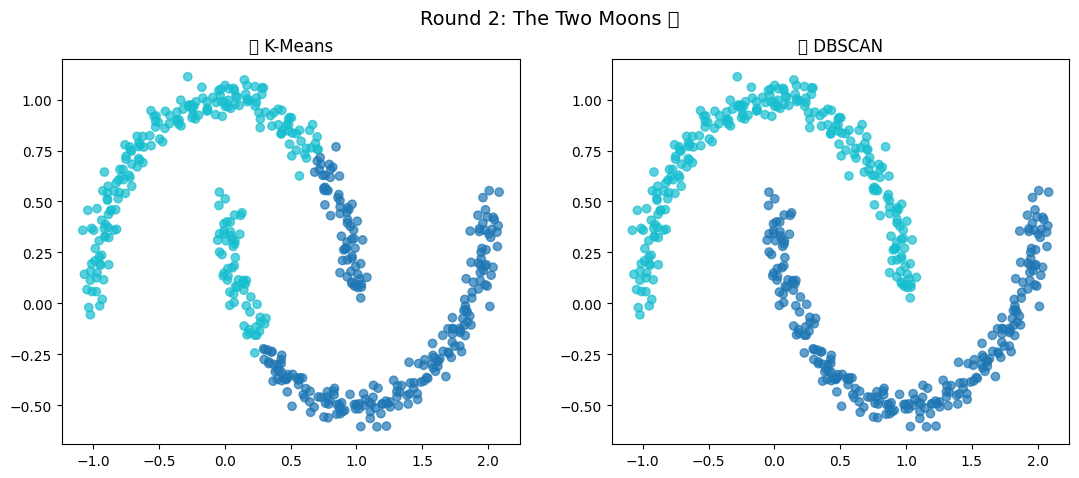

In [4]:
X_moons, _ = make_moons(n_samples=500, noise=0.05, random_state=42)

km_labels = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_moons)
db_labels = DBSCAN(eps=0.2, min_samples=5).fit_predict(X_moons)

plot_duel(X_moons, km_labels, db_labels, 'Round 2: The Two Moons 🌙')

**Round 2 verdict:** 🟢 DBSCAN wins by knockout! K-Means sliced straight through both moons (it can only draw round territories around centroids). DBSCAN followed the dense curve of each moon perfectly — shape doesn't matter, only **density**.

### 🥊 Round 3: Outliers Enter the Arena 🗑️

Real data is messy. Let's add 25 random "outlier" points scattered everywhere — think of them as fraudulent transactions hiding among normal ones. 💳

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128465 (\N{WASTEBASKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


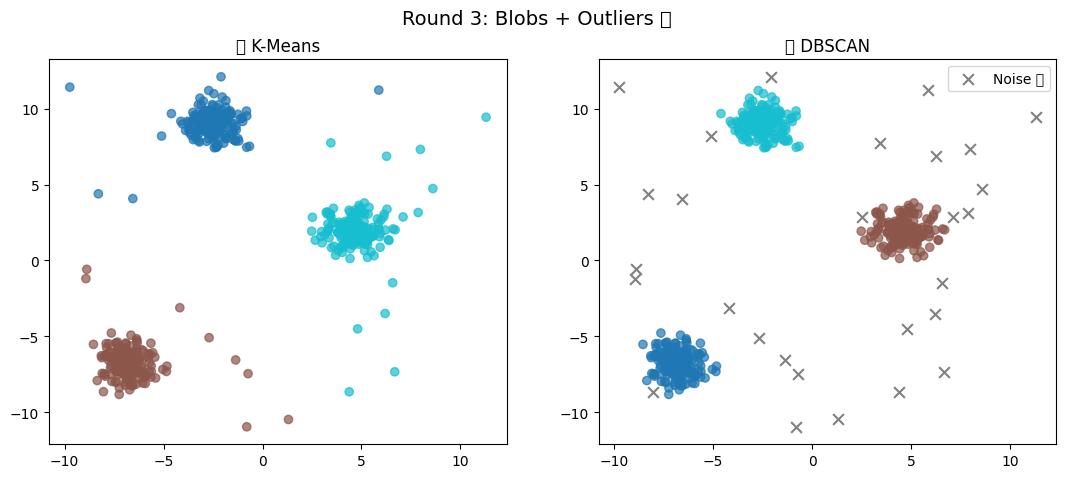

🟢 DBSCAN flagged 28 points as NOISE (label = -1)
🔵 K-Means flagged... zero. It CANNOT say 'this point belongs to nothing' — every point is forced into a cluster!


In [5]:
rng = np.random.default_rng(42)
outliers = rng.uniform(low=-12, high=12, size=(25, 2))
X_messy = np.vstack([X_blobs, outliers])

km_labels = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_messy)
db_labels = DBSCAN(eps=0.7, min_samples=5).fit_predict(X_messy)

plot_duel(X_messy, km_labels, db_labels, 'Round 3: Blobs + Outliers 🗑️')

n_noise = (db_labels == -1).sum()
print(f"🟢 DBSCAN flagged {n_noise} points as NOISE (label = -1)")
print("🔵 K-Means flagged... zero. It CANNOT say 'this point belongs to nothing' — every point is forced into a cluster!")

**Round 3 verdict:** 🟢 DBSCAN again. Look at the left plot — K-Means assigned every random outlier to one of the three clusters, as if a transaction in the middle of nowhere is a "normal customer". DBSCAN marked them with gray ✖ — *"you belong to nothing"*. **This is exactly how density-based methods catch fraud and anomalies.**

### 🎯 Mini Exercise 1 — Break DBSCAN 😈

DBSCAN's superpower comes from its `eps` setting: **how close must points be to count as neighbors?** Wrong eps = disaster.

Re-run the two moons with `eps=0.05` (too strict), then with `eps=0.5` (too generous). What happens in each case?

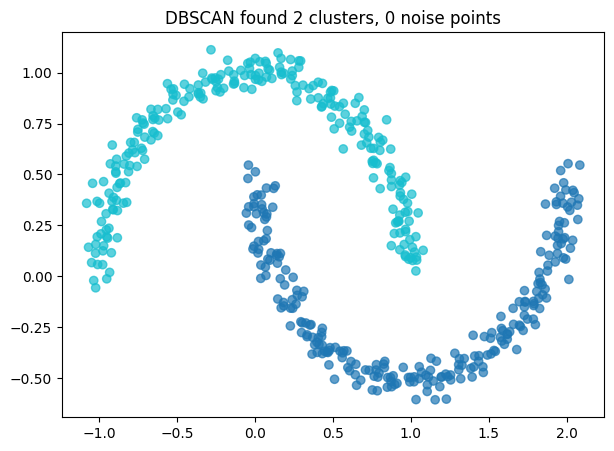

In [10]:
# TO-DO: try eps=0.05 first, then eps=0.5. Describe what you see!
db_labels = DBSCAN(eps=0.35, min_samples=5).fit_predict(X_moons)

noise = db_labels == -1
plt.figure(figsize=(7, 5))
plt.scatter(X_moons[~noise, 0], X_moons[~noise, 1], c=db_labels[~noise], cmap='tab10', alpha=0.7)
plt.scatter(X_moons[noise, 0], X_moons[noise, 1], c='gray', marker='x', s=60)
plt.title(f'DBSCAN found {len(set(db_labels)) - (1 if noise.any() else 0)} clusters, {noise.sum()} noise points')
plt.show()

### 🎯 Mini Exercise 2 — Your Turn to Referee 📋

For each real-world scenario below, write which algorithm YOU would choose and one sentence why:

1. A delivery company wants to place **exactly 4 warehouses** in a city, each serving the nearest customers. 📦
2. A bank wants to **flag suspicious transactions** that don't look like any normal spending pattern. 💳
3. A telescope scans the sky and astronomers want to find **star clusters of unknown shapes and unknown count**. 🌌

*✍️ My answers:*
1. ...
2. ...
3. ...

## The GOLDEN Question 🏆

DBSCAN beat K-Means in 2 out of 3 rounds today. So here's the puzzle: **why is K-Means still the most widely used clustering algorithm in the real world?** 🤔

*Hints: Which algorithm was easier to configure today — choosing K, or tuning eps in Exercise 1? What happens with millions of points? And in the mall lab, did we NEED weird shapes?*